# S&P Global – SNF Mining Scraper

Orchestration notebook for the modular SNF Mining scrape pipeline.

**Source package**: `gnt/data/download/sources/snf_mining/`

| Module | Responsibility |
|--------|---------------|
| `browser.py` | Chrome WebDriver lifecycle |
| `auth.py` | Login / logout |
| `id_collector.py` | Paginate screener → collect mine IDs |
| `db.py` | DuckDB schema & persistence |
| `detail_scraper.py` | Dispatch per-ID information blocks |
| `blocks/` | Individual data-extraction blocks (extend here) |
| `workflow.py` | Full pipeline orchestrator |

Run the **Quick Start** section to execute the full workflow, or step through the individual sections below for development / debugging.


## Setup

In [1]:
import sys
import logging
from pathlib import Path

# Make the package importable from this notebook location
REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Paths – DB and raw data live at data/snf_mining/raw/ (mirrors misc.py convention)
from gnt.data.download.sources.snf_mining.config import DEFAULT_DB_PATH, DATA_DIR

CREDENTIALS_PATH = REPO_ROOT / "orchestration/secrets/spglobal.credentials.json"
DB_PATH = DEFAULT_DB_PATH  # <repo_root>/data/snf_mining/raw/snf_mining.duckdb

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)

print("REPO_ROOT:   ", REPO_ROOT)
print("DATA_DIR:    ", DATA_DIR)
print("DB_PATH:     ", DB_PATH)


REPO_ROOT:    C:\Users\schulz0022\Documents\gnt
DATA_DIR:     C:\Users\schulz0022\Documents\gnt\data\snf_mining\raw
DB_PATH:      C:\Users\schulz0022\Documents\gnt\data\snf_mining\raw\snf_mining.duckdb


---
## Step-by-Step Walkthrough

Use these cells for interactive development and debugging.

### Step 1 – Load credentials & open DB

In [2]:
from gnt.data.download.sources.snf_mining.auth import load_credentials
from gnt.data.download.sources.snf_mining.db import get_connection

credentials = load_credentials(CREDENTIALS_PATH)
conn = get_connection(DB_PATH)
print("DB ready:", DB_PATH)


DB ready: C:\Users\schulz0022\Documents\gnt\data\snf_mining\raw\snf_mining.duckdb


### Step 2 – Open Chrome & login

In [3]:
from gnt.data.download.sources.snf_mining.browser import ManagedBrowser
from gnt.data.download.sources.snf_mining.auth import login
from gnt.data.download.sources.snf_mining.config import EXPORT_DIR

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

browser = ManagedBrowser(headless=False, download_dir=str(EXPORT_DIR))
driver = browser.__enter__()   # keep driver alive across cells; call browser.quit() at the end
login(driver, credentials)

print("Download dir:", EXPORT_DIR)

2026-03-13 16:55:58,465 [INFO] WDM: ====== WebDriver manager ======
2026-03-13 16:55:59,112 [INFO] WDM: Get LATEST chromedriver version for google-chrome
2026-03-13 16:55:59,156 [INFO] WDM: Get LATEST chromedriver version for google-chrome
2026-03-13 16:55:59,205 [INFO] WDM: Driver [C:\Users\schulz0022\.wdm\drivers\chromedriver\win64\145.0.7632.117\chromedriver-win32/chromedriver.exe] found in cache
2026-03-13 16:56:00,256 [INFO] gnt.data.download.sources.snf_mining.auth: Navigating to login page …
2026-03-13 16:56:04,061 [INFO] gnt.data.download.sources.snf_mining.auth: Password submitted – waiting for dashboard …
2026-03-13 16:56:12,580 [INFO] gnt.data.download.sources.snf_mining.auth: Cookie banner accepted.
2026-03-13 16:56:12,580 [INFO] gnt.data.download.sources.snf_mining.auth: Login successful.


Download dir: C:\Users\schulz0022\Documents\gnt\data\snf_mining\raw\exports


### Step 3 – Phase: COLLECTION (export screener and ingest IDs)

The collector runs the screen, triggers **Export → Results As Values**, waits for the XLSX download, extracts IDs, and upserts them into DuckDB.

This phase now always performs a fresh export on each run.

In [4]:
from pathlib import Path

from gnt.data.download.sources.snf_mining.id_collector import collect_all_ids
from gnt.data.download.sources.snf_mining.db import get_screener_state
from gnt.data.download.sources.snf_mining.config import EXPORT_DIR, SCREENER_KEY

# collect_all_ids runs screen -> export -> download -> parse -> upsert
mine_ids = collect_all_ids(driver, conn, download_dir=EXPORT_DIR)
print(f"Total IDs in DB after collection: {len(mine_ids)}")

2026-03-13 16:56:12,586 [INFO] gnt.data.download.sources.snf_mining.id_collector: Opening screener …
2026-03-13 16:56:15,340 [INFO] gnt.data.download.sources.snf_mining.id_collector: Screen submitted – waiting for results …
2026-03-13 16:56:17,433 [INFO] gnt.data.download.sources.snf_mining.id_collector: Screener results loaded; starting export.
2026-03-13 16:57:02,753 [INFO] gnt.data.download.sources.snf_mining.id_collector: ID collection complete – 38384 IDs extracted from export (0 newly inserted).


Total IDs in DB after collection: 38384


### Step 4 – Inspect collected IDs in DuckDB

In [5]:
from gnt.data.download.sources.snf_mining.db import count_scraped_ids

total, scraped = count_scraped_ids(conn)
print(f"Mines in DB: {total} total | {scraped} with completed detail pass | {total - scraped} pending")

# Full table overview
conn.execute("""
    SELECT COUNT(*) AS total_ids,
           COUNT(detail_scraped_at) AS detail_done,
           MIN(id_scraped_at) AS first_collected,
           MAX(id_scraped_at) AS last_collected
    FROM mines
""").df()

Mines in DB: 38384 total | 0 with completed detail pass | 38384 pending


,total_ids,detail_done,first_collected,last_collected
0,38384,0,2026-03-12 17:06:57.502831+01:00,2026-03-13 10:25:14.817635+01:00


In [6]:
from gnt.data.download.sources.snf_mining import scrape_detail_exports
from gnt.data.download.sources.snf_mining.config import DOWNLOAD_WAIT_SECONDS
from gnt.data.download.sources.snf_mining.db import get_unscraped_ids

# STEP 5A — scrape XLS + Property Profile geometries (no XLS parsing yet)
pending = sorted(
    get_unscraped_ids(conn),
    key=lambda mid: int(mid) if str(mid).isdigit() else str(mid),
)
print(f"Preparing detail scraping for {len(pending)} mine(s). (may take a while)")

result = scrape_detail_exports(driver, conn, mine_ids=pending, wait=8, download_wait=DOWNLOAD_WAIT_SECONDS)
print(result)

Preparing detail scraping for 38384 mine(s). (may take a while)


2026-03-13 16:57:19,451 [INFO] gnt.data.download.sources.snf_mining.workflow: Retrying (1/3) for discover subsections for mine_id=24427 after error: Message: no such element: Unable to locate element: {"method":"css selector","selector":"nav[data-testid='side-navigation']"}
  (Session info: chrome=145.0.7632.160); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x407dd3
	0x407e14
	0x211db0
	0x25c20a
	0x25c4ab
	0x2519d1
	0x27ea84
	0x2518c4
	0x27ec04
	0x29b621
	0x27e7d6
	0x250049
	0x250e04
	0x666924
	0x661bf7
	0x67f5a0
	0x420f58
	0x42891d
	0x410648
	0x410812
	0x3fa21a
	0x74bc5d49
	0x7764d83b
	0x7764d7c1

2026-03-13 16:57:19,969 [INFO] gnt.data.download.sources.snf_mining.workflow: Retrying (2/3) for discover subsections for mine_id=24427 after error: Message: no such element: Unable to locate element: {"method":"css selector","sel

KeyboardInterrupt: 

In [18]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException

def click_side_nav_toggle(driver, timeout=5):
    try:
        btn = WebDriverWait(driver, timeout).until(
            EC.presence_of_element_located(
                (By.CSS_SELECTOR, 'button[aria-label="Collapse Page Side Navigation Menu"]')
            )
        )
        btn.click()
        return True
    except TimeoutException:
        # Not present / not clickable right now
        return False
    
click_side_nav_toggle(driver)

True

In [62]:
def get_sidebar_sections_and_subsections(driver, timeout=8):
    wrapper = WebDriverWait(driver, timeout).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "div.page-sidebar-wrapper"))
    )

    nav = wrapper.find_element(By.CSS_SELECTOR, "nav[data-testid='side-navigation']")

    # Detect layout: large window uses inline expansion (links inside the <li>),
    # small window uses a flyout panel (.css-1fpbe4u) injected outside the <li>.
    def is_flyout_layout():
        # Click a button and check where the links appear
        test_btns = nav.find_elements(
            By.XPATH, ".//li[@data-type='menu-item']//button[@aria-haspopup='true']"
        )
        if not test_btns:
            return False
        try:
            test_btns[0].click()
            WebDriverWait(driver, timeout).until(
                lambda d: test_btns[0].get_attribute("aria-expanded") == "true"
            )
            # Flyout layout injects a panel with a <p> header outside the nav
            flyouts = wrapper.find_elements(By.XPATH, ".//div[contains(@class,'css-1fpbe4u')]")
            return len(flyouts) > 0
        except Exception:
            return False

    flyout = is_flyout_layout()

    # If large-window layout: try clicking "Expand All" first
    if not flyout:
        try:
            expand_all_btn = nav.find_element(By.CSS_SELECTOR, "button[data-type='expand-all']")
            if expand_all_btn.get_attribute("aria-expanded") == "false":
                expand_all_btn.click()
        except Exception:
            pass

    results = {}
    menu_items = nav.find_elements(By.XPATH, ".//li[@data-type='menu-item']")

    for item in menu_items:
        try:
            btn = item.find_element(By.XPATH, ".//button[@aria-haspopup='true']")
            label = btn.find_element(By.XPATH, ".//span[@data-button-text='true']").text.strip()
        except Exception:
            continue

        if not label:
            continue

        # Expand if not already
        if btn.get_attribute("aria-expanded") != "true":
            try:
                btn.click()
            except Exception:
                driver.execute_script("arguments[0].click();", btn)
            WebDriverWait(driver, timeout).until(
                lambda d: btn.get_attribute("aria-expanded") == "true"
            )

        if flyout:
            # Small-window layout: links are in the flyout panel with a matching <p> header
            panel = WebDriverWait(driver, timeout).until(
                EC.visibility_of_element_located((
                    By.XPATH,
                    f"//div[contains(@class,'css-1fpbe4u')]"
                    f"[.//p[normalize-space(text())='{label}']]"
                ))
            )
            links = panel.find_elements(By.XPATH, ".//ul//a[@data-type='link']")
        else:
            # Large-window layout: links are inline inside the same <li>
            links = item.find_elements(By.XPATH, ".//ul//a")

        results[label] = [
            {"label": a.text.strip(), "href": a.get_attribute("href")}
            for a in links
            if a.text.strip() and a.is_displayed()
        ]

    return results

get_sidebar_sections_and_subsections(driver)

{'My Links': [],
 'Profile': [{'label': 'Property Profile',
   'href': 'https://www.capitaliq.spglobal.com/web/client#metalsAndMiningProperty/profile?ID=64665'},
  {'label': 'Location, Map & Claims',
   'href': 'https://www.capitaliq.spglobal.com/web/client#metalsAndMiningProperty/location?ID=64665'},
  {'label': 'Work History',
   'href': 'https://www.capitaliq.spglobal.com/web/client#metalsAndMiningProperty/workHistory?ID=64665'}],
 'Ownership': [{'label': 'Ownership',
   'href': 'https://www.capitaliq.spglobal.com/web/client#metalsAndMiningProperty/combinedOwnership?ID=64665'},
  {'label': 'Ownership Structure',
   'href': 'https://www.capitaliq.spglobal.com/web/client#metalsAndMiningProperty/ownershipStructure?ID=64665'}]}

In [71]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException, StaleElementReferenceException

# ---------------------------------------------------------------------------
# Known toolbar action data-ids
# ---------------------------------------------------------------------------
class ToolbarAction:
    ADD_TO_SHORTCUTS = 26
    PRINT            = 1
    EXPORT_EXCEL     = 32
    EXPORT_PDF       = 31
    EXPORT_WORD      = 33
    BUILD_REPORT     = 22
    FILTERS          = 57

# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------
_RETRY_EXC = (NoSuchElementException, StaleElementReferenceException)

def _safe_call(fn):
    """Swallows transient Selenium exceptions so WebDriverWait keeps retrying."""
    try:
        return fn()
    except _RETRY_EXC:
        return None

def _find_toolbar(driver, action_data_id, timeout):
    """Finds the first snl-hui-toolbar containing a toolbutton with the given data-id."""
    return WebDriverWait(driver, timeout).until(
        EC.presence_of_element_located((
            By.XPATH,
            f"//div[contains(@class,'snl-hui-toolbar')]"
            f"[.//a[contains(@class,'hui-toolbutton') and @data-id='{action_data_id}']]"
        ))
    )

def _find_target(scope, action_data_id):
    """
    Returns the best candidate toolbutton link in scope:
    prefers a visible one, falls back to any match.
    """
    candidates = scope.find_elements(
        By.XPATH,
        f".//a[@data-id='{action_data_id}' and contains(@class,'hui-toolbutton')]"
    )
    if not candidates:
        raise NoSuchElementException(f"No hui-toolbutton with data-id={action_data_id}")
    visible = [a for a in candidates if a.is_displayed()]
    return visible[0] if visible else candidates[0]

def _open_parent_dropdown(driver, target, timeout):
    """Opens the nearest dropdown ancestor of target if it exists and is not already open."""
    try:
        parent_li = target.find_element(
            By.XPATH, "./ancestor::li[contains(@class,'dropdown')][1]"
        )
        if "open" not in (parent_li.get_attribute("class") or ""):
            toggle = parent_li.find_element(By.XPATH, "./a[@data-toggle='dropdown']")
            try:
                toggle.click()
            except Exception:
                driver.execute_script("arguments[0].click();", toggle)
            WebDriverWait(driver, timeout).until(
                lambda d: "open" in (parent_li.get_attribute("class") or "")
            )
            return True  # dropdown was opened; caller should re-find target
    except NoSuchElementException:
        pass  # top-level item, no dropdown needed
    return False

# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------
def click_toolbar_action(driver, action_data_id, toolbar_el=None, timeout=8):
    """
    Clicks a toolbar action by its data-id.

    Automatically discovers the toolbar if toolbar_el is not provided,
    and opens any parent dropdown if the action is nested.

    :param driver:         Selenium WebDriver
    :param action_data_id: data-id of the target action (use ToolbarAction constants)
    :param toolbar_el:     Optional scoping WebElement; auto-discovered if None
    :param timeout:        WebDriverWait timeout in seconds

    Example:
        click_toolbar_action(driver, ToolbarAction.EXPORT_EXCEL)
    """
    action_data_id = str(action_data_id)
    scope = toolbar_el or _find_toolbar(driver, action_data_id, timeout)

    target = WebDriverWait(driver, timeout).until(
        lambda d: _safe_call(lambda: _find_target(scope, action_data_id))
    )

    if _open_parent_dropdown(driver, target, timeout):
        target = _find_target(scope, action_data_id)  # re-find after dropdown opens

    WebDriverWait(driver, timeout).until(EC.visibility_of(target))
    try:
        target.click()
    except Exception:
        driver.execute_script("arguments[0].click();", target)


In [72]:
# Simplest — auto-discovers toolbar
click_toolbar_action(driver, ToolbarAction.EXPORT_EXCEL)


In [ ]:
from selenium.webdriver.common.by import By
from urllib.parse import urlparse, parse_qs
import re, io, requests
import numpy as np
from PIL import Image
from shapely.ops import unary_union
from shapely.geometry import shape
import cv2
from rasterio.features import shapes
from rasterio.transform import from_bounds
import rasterio
from pyproj import Transformer
from shapely.ops import transform as shp_transform
from PIL import Image as PILImage



def make_hsv_range(h, s, v, h_tol=12, s_tol=60, v_tol=60):
    """Returns a list containing one (lo, hi) tuple."""
    lo = np.array([max(0,   h - h_tol), max(0,   s - s_tol), max(0,   v - v_tol)])
    hi = np.array([min(180, h + h_tol), min(255, s + s_tol), min(255, v + v_tol)])
    return [(lo, hi)]


# ── Per-layer color ranges (HSV, OpenCV scale: H=0-180, S/V=0-255) ──────────
#
# Values decoded from actual legend swatches:
#   Property fill   #377DD5  →  HSV(107, 189, 213)   steel blue
#   Linked claims   #AA66CD  →  HSV(140, 126, 205)   purple
#   All claims      #EAC476  →  HSV( 20, 126, 234)   golden yellow
#   Border          #000000  →  near-black, V < 30
#
# !! If property fill still doesn't mask, run diagnose_wms_colors(driver)
# !! and replace the HSV triplet in make_hsv_range() with the printed values.

COLOR_RANGES = {
    "property_fill":   make_hsv_range(107, 189, 213, h_tol=10, s_tol=60, v_tol=60),
    "property_border": [(np.array([0,   0,   0]), np.array([180, 255,  30]))],
    "linked":          make_hsv_range(140, 126, 205, h_tol=15, s_tol=60, v_tol=60),
    "all_claims":      make_hsv_range( 20, 126, 234, h_tol=12, s_tol=60, v_tol=60),
}

# ── Composite targets (combine ranges from multiple layers) ──────────────────
COMPOSITE_TARGETS = {
    "property":   COLOR_RANGES["property_fill"],
    "linked":          COLOR_RANGES["linked"],
}


def build_color_mask(img_rgba, target: str = "property") -> np.ndarray:
    """
    Returns a binary uint8 mask (255 = claim pixel) for the given target.

    Parameters
    ----------
    img_rgba : PIL Image or H×W×4 numpy array (RGBA)
    target   : key from COMPOSITE_TARGETS —
               'property', 'property_fill', 'property_border',
               'linked', 'all_claims', 'all'
    """
    if isinstance(img_rgba, PILImage.Image):
        img_rgba = np.array(img_rgba.convert("RGBA"))

    alpha = img_rgba[:, :, 3]
    bgr   = cv2.cvtColor(img_rgba[:, :, :3], cv2.COLOR_RGB2BGR)
    hsv   = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    ranges = COMPOSITE_TARGETS.get(target)
    if ranges is None:
        raise ValueError(
            f"Unknown target '{target}'. "
            f"Choose from: {list(COMPOSITE_TARGETS)}"
        )

    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lo, hi in ranges:          # each item is a (lo, hi) tuple
        mask |= cv2.inRange(hsv, lo, hi)

    mask[alpha == 0] = 0           # exclude fully transparent pixels
    return mask

def get_wms_tiles(driver, components="1"):
    """
    Returns all loaded WMS tiles for the given components value.
    Layer type (property/linked/all_claims) is determined by color, not components.
    """
    map_id = get_map_element_id(driver)
    tile_imgs = driver.find_elements(
        By.CSS_SELECTOR,
        f"#{map_id} .leaflet-tile-pane img.leaflet-tile-loaded"
    )

    tiles = []
    for img in tile_imgs:
        src   = img.get_attribute("src")   or ""
        style = img.get_attribute("style") or ""

        if f"components={components}" not in src:
            continue
        if "display: none" in style:
            continue
        if "bb_mininglocation" not in src:       # only mining claim tiles
            continue

        bbox_m = re.search(r"bbox=([-\d.,]+)", src)
        w_m    = re.search(r"width=(\d+)",     src)
        h_m    = re.search(r"height=(\d+)",    src)
        t_m    = re.search(r"translate3d\(([-\d.]+)px,\s*([-\d.]+)px", style)

        if not (bbox_m and w_m and h_m):
            continue

        tiles.append({
            "src":    src,
            "bbox":   list(map(float, bbox_m.group(1).split(","))),
            "width":  int(w_m.group(1)),
            "height": int(h_m.group(1)),
            "tx":     float(t_m.group(1)) if t_m else 0,
            "ty":     float(t_m.group(2)) if t_m else 0,
        })

    print(f"  Found {len(tiles)} mining claim tiles")
    return tiles


def tiles_to_polygons(driver, target="property", components="1"):
    """
    Fetch all WMS tiles, apply color mask for `target`, vectorize and georeference.
    `target` selects which color layer to extract — not which component.

    Valid targets: 'property', 'property_fill', 'property_border',
                   'linked', 'all_claims', 'all'
    """
    tiles = get_wms_tiles(driver, components=components)
    if not tiles:
        raise ValueError("No tiles found.")

    all_polys_3857 = []

    for i, tile in enumerate(tiles):
        arr = fetch_tile(driver, tile["src"])
        minx, miny, maxx, maxy = tile["bbox"]
        w, h = tile["width"], tile["height"]

        if arr[:, :, 3].max() == 0:
            continue  # fully transparent tile, skip

        mask = build_color_mask(arr, target=target)

        if mask.max() == 0:
            continue  # target color not present in this tile

        print(f"  Tile {i}: masked pixels={mask.sum()//255}  bbox={tile['bbox']}")

        transform = from_bounds(minx, miny, maxx, maxy, w, h)
        for geom, val in shapes(mask, mask=(mask > 0), transform=transform):
            if val > 0:
                all_polys_3857.append(shape(geom))

    print(f"  Total raw polygons: {len(all_polys_3857)}")
    return all_polys_3857


def extract_claim_geometry_from_tiles(driver, target="property", components="1"):
    """
    Full pipeline → unioned WGS84 Shapely geometry for the requested color target.

    target options
    ──────────────
    'property'       : blue fill + black border of the main claim
    'linked'         : purple fill of linked claims
    'all_claims'     : golden yellow all-claims overlay
    'all'            : union of all three
    """
    polys_3857 = tiles_to_polygons(driver, target=target, components=components)

    if not polys_3857:
        raise ValueError(
            f"No polygons found for target='{target}'. "
            "Run diagnose_wms_colors(driver) to check actual tile colors."
        )

    unioned_3857  = unary_union(polys_3857)
    transformer   = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
    unioned_wgs84 = shp_transform(transformer.transform, unioned_3857)

    print(f"  Result: {unioned_wgs84.geom_type}  bounds={unioned_wgs84.bounds}")
    return unioned_wgs84


# ── Usage ─────────────────────────────────────────────────────────────────────
geometry_linked     = extract_claim_geometry_from_tiles(driver, target="linked")
geometry_property   = extract_claim_geometry_from_tiles(driver, target="property")


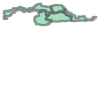

In [131]:
geometry_linked

### Step 5 – Phase: DETAIL in two steps

> Step 5A scrapes and stores XLS files, and always captures Property Profile geometries.

- Discovers all available subsections per mine profile
- Downloads one XLS per subsection into a managed filesystem layout
- Records export metadata in DuckDB
- Stores `linked` and `property` geometries from the Property Profile page in DuckDB

> Step 5B parses downloaded XLS files and writes extracted cells to DuckDB.

This separation makes scraping rerunnable without re-parsing, and parsing rerunnable without driving Selenium again.

In [ ]:
from gnt.data.download.sources.snf_mining import parse_detail_exports

# STEP 5B — parse/extract from already-downloaded XLS files (no Selenium scraping)
result = parse_detail_exports(conn)
print(result)

In [ ]:
### Step 6 – Logout & cleanup

collecting page 1
collected 164 IDs
['55436', '56392', '69169', '36097', '56666', '60997', '64074', '24451', '57900', '24850', '34685', '57901', '29572', '82801', '31261', '53895', '76207', '67222', '67292', '67537']


In [6]:
from gnt.data.download.sources.snf_mining.auth import logout

logout(driver)
browser.quit()
conn.close()
print("Session closed.")


2026-03-13 10:13:31,201 [INFO] gnt.data.download.sources.snf_mining.auth: Logout successful.


Session closed.
